Material for the book Probability and Statistics for Data Science. A free preprint, videos, code, slides and solutions to exercises are available at https://www.ps4ds.net/

Probabilistic modeling of the presence of different plant species in the Eastern coastal states of the United States.\
Topics and relevant videos: [Modeling multiple discrete variables](https://youtu.be/gxMG3tE90gA?si=Hluzmq3JrEkDTyng) 

Author: Carlos Fernandez-Granda

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

with open("../data/plants.pkl", "rb") as f:
    plants = pickle.load(f)

In [3]:
observed = {
    'ME': 0, 'NH': 0, 'MA': 1, 'RI': 0, 'CT': 1, 'NY': 1, 'NJ': 1, 'DE': 1, 'MD': 1, 'NC': 1, 
    'SC': 0, 'GA': 0, 'FL': 1, 'AL': 1, 'MS': 0, 'LA': 0, 'TX': 0
}

In [4]:
# 1. Get total number of plants using 'ME' array length
num_plants = len(plants["ME"])

matching_plants = []

# 2. Check each plant index one by one
for i in range(num_plants):
    pattern_matches = True

    # 3. Check every state in your observed dictionary
    for state, observed_val in observed.items():
        actual_val = plants[state][i]

        if actual_val != observed_val:
            pattern_matches = False
            break  # Stop checking this plant if one state fails

    # 4. Save the index if all states matched
    if pattern_matches:
        matching_plants.append(i)

# Output results
if matching_plants:
    print(
        f"Found {len(matching_plants)} plant(s) matching the pattern at indices: {matching_plants}"
    )
else:
    print("No plant matches this exact pattern.")

No plant matches this exact pattern.


In [5]:
# 1. Extract vectors from the plants dictionary
va = plants["VA"]
sc = plants["SC"]
nc = plants["NC"]

# --- CHART 1: Not Conditioned on NC ---
# Marginal P(VA = 1)
p_va_marginal = np.mean(va == 1)

# Conditional P(VA = 1 | SC = 0)
p_va_sc0 = np.mean(va[sc == 0] == 1)

# Conditional P(VA = 1 | SC = 1)
p_va_sc1 = np.mean(va[sc == 1] == 1)

# --- CHART 2: Conditioned on NC = 0 ---
# P(VA = 1 | NC = 0)
p_va_nc0 = np.mean(va[nc == 0] == 1)

# P(VA = 1 | SC = 0, NC = 0)
p_va_sc0_nc0 = np.mean(va[(sc == 0) & (nc == 0)] == 1)

# P(VA = 1 | SC = 1, NC = 0)
p_va_sc1_nc0 = np.mean(va[(sc == 1) & (nc == 0)] == 1)

# --- CHART 3: Conditioned on NC = 1 ---
# P(VA = 1 | NC = 1)
p_va_nc1 = np.mean(va[nc == 1] == 1)

# P(VA = 1 | SC = 0, NC = 1)
p_va_sc0_nc1 = np.mean(va[(sc == 0) & (nc == 1)] == 1)

# P(VA = 1 | SC = 1, NC = 1)
p_va_sc1_nc1 = np.mean(va[(sc == 1) & (nc == 1)] == 1)

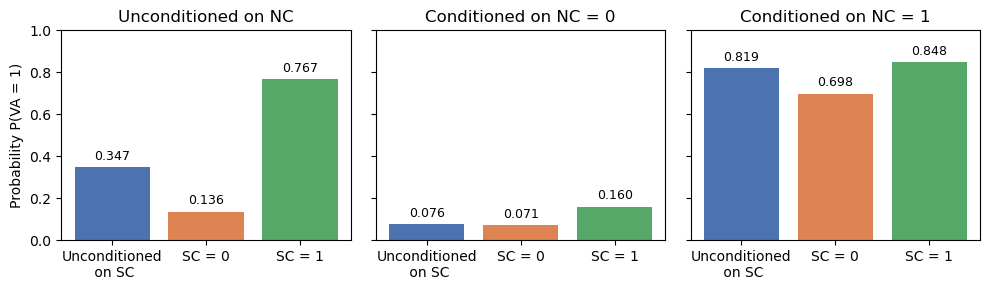

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)

categories = ["Unconditioned\n on SC", "SC = 0", "SC = 1"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

# Subplot 1: Not Conditioned on NC
bars1 = axes[0].bar(
    categories, [p_va_marginal, p_va_sc0, p_va_sc1], color=colors
)
axes[0].set_title("Unconditioned on NC")
axes[0].set_ylabel("Probability P(VA = 1)")
axes[0].set_ylim(0, 1.0)

# Subplot 2: Conditioned on NC = 0
bars2 = axes[1].bar(
    categories, [p_va_nc0, p_va_sc0_nc0, p_va_sc1_nc0], color=colors
)
axes[1].set_title("Conditioned on NC = 0")

# Subplot 3: Conditioned on NC = 1
bars3 = axes[2].bar(
    categories, [p_va_nc1, p_va_sc0_nc1, p_va_sc1_nc1], color=colors
)
axes[2].set_title("Conditioned on NC = 1")


# Helper function to add value labels on top of bars
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )


add_labels(axes[0], bars1)
add_labels(axes[1], bars2)
add_labels(axes[2], bars3)

plt.tight_layout()
plt.show()

In [8]:
md = plants["MD"]
p_va_md1_nc1 = np.mean(va[(md == 1) & (nc == 1)] == 1)
print("P(VA = 1 | MD = 1, NC = 1) =",np.around(p_va_md1_nc1,3))

P(VA = 1 | MD = 1, NC = 1) = 0.967


In [9]:
ct = plants["CT"]
ma = plants["MA"]
ny = plants["NY"]

p_ct_ma1_ny0 = np.mean( ct[(ma == 1) & (ny == 0)] == 1)
p_va_md1_sc1 = np.mean(va[(md == 1) & (sc == 1)] == 1)
print("P(CT = 1 | MA = 1, NY = 0) =",np.around(p_ct_ma1_ny0,3))
print("P(VA = 1 | MD = 1, SC = 1) =",np.around(p_va_md1_sc1,3))
print("P(CT = 1 | MA = 1, NY = 0)P(VA = 1 | MD = 1, NC = 1) =",np.around(p_va_md1_sc1 * p_ct_ma1_ny0,3))

P(CT = 1 | MA = 1, NY = 0) = 0.203
P(VA = 1 | MD = 1, SC = 1) = 0.971
P(CT = 1 | MA = 1, NY = 0)P(VA = 1 | MD = 1, NC = 1) = 0.197
